# Прогнозирование посещаемости мероприятий на основе методов машинного обучения

**Тема практики:** Прогнозирование посещаемости мероприятий на основе методов машинного обучения

**Цель:** Разработать и протестировать ML-модель для прогнозирования количества участников мероприятий на основе исторических данных.

---

## Содержание
1. Загрузка и первичный анализ данных
2. Очистка и подготовка данных
3. Разведочный анализ данных (EDA)
4. Создание новых признаков (Feature Engineering)
5. Подготовка данных для моделирования
6. Обучение моделей машинного обучения
7. Сравнение моделей и выбор лучшей
8. Анализ важности признаков
9. Выводы и рекомендации для организаторов

## 1. Загрузка библиотек и данных

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)

# Для корректного отображения русских шрифтов
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Библиотеки успешно загружены')

Библиотеки успешно загружены


In [2]:
# Загрузка данных
df_raw = pd.read_csv('data/events_raw.csv')

print(f'Загружено записей: {len(df_raw)}')
print(f'Количество признаков: {len(df_raw.columns)}')
print(f'\nПервые 5 записей:')
df_raw.head()

Загружено записей: 15585
Количество признаков: 20

Первые 5 записей:


,event_id,name_clean,url,starts_at,start_year,start_month,start_dow,start_hour,season,is_weekend,holiday,category,city,price,is_free,ad_budget,capacity,lead_days,registrations,participants
0,24598,Восход солнца,https://artyfarty.timepad.ru/event/24598/,2022-04-30T00:00:00+0300,2022,4,4,21,spring,1,0,Не указано,Другие,0,1,2454,49,13,47,32
1,337530,Избавиться от стресса за 1 час - Мастер-класс,https://stolichnyy-gorod.timepad.ru/event/337530/,2019-12-21T17:00:00+0300,2019,12,5,14,winter,1,0,Психология и самопознание,Санкт-Петербург,650,0,5024,44,17,38,32
2,409457,Грандиозное шоу на теплоходе Рио-4 Музклуба Ма...,https://club-teatra.timepad.ru/event/409457/,2020-07-05T12:00:00+0300,2020,7,6,9,summer,1,0,Экскурсии и путешествия,Другие,750,0,2851,15,19,12,10
3,483633,Пир-Коучинг равных и интервизия: межрегиональн...,https://NovosibirskCoachingClub.timepad.ru/eve...,2020-10-10T19:00:00+0300,2020,10,5,16,autumn,1,0,Другие события,Другие,0,1,3616,49,18,56,42
4,685268,Игра-тренинг Денежный поток,https://ekaterina-rotmistrova.timepad.ru/event...,2020-02-08T14:00:00+0300,2020,2,5,11,winter,1,0,Интеллектуальные игры,Москва,650,0,7844,54,17,52,45


In [3]:
# Информация о датасете
print('Информация о типах данных:')
print('=' * 50)
df_raw.info()

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15585 entries, 0 to 15584
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   event_id       15585 non-null  int64 
 1   name_clean     15585 non-null  object
 2   url            15585 non-null  object
 3   starts_at      15585 non-null  object
 4   start_year     15585 non-null  int64 
 5   start_month    15585 non-null  int64 
 6   start_dow      15585 non-null  int64 
 7   start_hour     15585 non-null  int64 
 8   season         15585 non-null  object
 9   is_weekend     15585 non-null  int64 
 10  holiday        15585 non-null  int64 
 11  category       15585 non-null  object
 12  city           15585 non-null  object
 13  price          15585 non-null  int64 
 14  is_free        15585 non-null  int64 
 15  ad_budget      15585 non-null  int64 
 16  capacity       15585 non-null  int64 
 17  lead_days      15585 non-null  int64 
 18 

In [4]:
# Статистика по числовым признакам
print('Статистика по числовым признакам:')
df_raw.describe()

Статистика по числовым признакам:


,event_id,start_year,start_month,start_dow,start_hour,is_weekend,holiday,price,is_free,ad_budget,capacity,lead_days,registrations,participants
count,1.558500e+04,15585.000000,15585.000000,15585.000000,15585.000000,15585.000000,15585.000000,15585.00000,15585.000000,15585.000000,15585.000000,15585.000000,15585.000000,15585.000000
mean,1.894710e+06,2021.434200,6.715881,3.185691,11.811165,0.322425,0.029644,448.76163,0.409496,9053.578762,67.948348,29.367790,66.635547,49.751171
std,3.423456e+05,0.960085,3.150974,1.997763,4.242665,0.467420,0.169608,628.06288,0.491757,7779.478653,61.482046,16.533776,62.704226,44.401988
min,2.459800e+04,2019.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1000.000000,10.000000,5.000000,5.000000,4.000000
25%,1.636541e+06,2021.000000,4.000000,1.000000,8.000000,0.000000,0.000000,0.00000,0.000000,3922.000000,27.000000,18.000000,26.000000,21.000000
50%,2.006428e+06,2022.000000,7.000000,3.000000,11.000000,0.000000,0.000000,250.00000,0.000000,6370.000000,46.000000,25.000000,45.000000,34.000000
75%,2.147529e+06,2022.000000,9.000000,5.000000,15.000000,1.000000,0.000000,650.00000,1.000000,11203.000000,87.000000,37.000000,85.000000,64.000000
max,3.657963e+06,2023.000000,12.000000,6.000000,23.000000,1.000000,1.000000,4400.00000,1.000000,60570.000000,600.000000,120.000000,694.000000,456.000000


## 2. Очистка и подготовка данных

In [5]:
# Проверка на пропуски
print('Пропущенные значения по колонкам:')
print('=' * 50)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct})
print(missing_df[missing_df['Пропуски'] > 0] if missing.sum() > 0 else 'Пропусков нет')

Пропущенные значения по колонкам:
Пропусков нет


In [6]:
# Проверка на дубликаты
duplicates = df_raw.duplicated().sum()
print(f'Количество дубликатов: {duplicates}')

if duplicates > 0:
    df_raw = df_raw.drop_duplicates()
    print(f'Дубликаты удалены. Осталось записей: {len(df_raw)}')

Количество дубликатов: 0


In [7]:
# Проверка целевой переменной (participants)
print('Статистика целевой переменной (participants):')
print('=' * 50)
print(f"Минимум: {df_raw['participants'].min()}")
print(f"Максимум: {df_raw['participants'].max()}")
print(f"Среднее: {df_raw['participants'].mean():.1f}")
print(f"Медиана: {df_raw['participants'].median():.1f}")
print(f"\nЗаписей с нулевой посещаемостью: {(df_raw['participants'] == 0).sum()}")
print(f"Записей с отрицательной посещаемостью: {(df_raw['participants'] < 0).sum()}")

Статистика целевой переменной (participants):
Минимум: 4
Максимум: 456
Среднее: 49.8
Медиана: 34.0

Записей с нулевой посещаемостью: 0
Записей с отрицательной посещаемостью: 0


In [8]:
# Создаем копию для обработки
df = df_raw.copy()

# Удаляем записи с нулевой или отрицательной посещаемостью (некорректные данные)
initial_count = len(df)
df = df[df['participants'] > 0]
removed = initial_count - len(df)
print(f'Удалено некорректных записей: {removed}')
print(f'Осталось записей: {len(df)}')

Удалено некорректных записей: 0
Осталось записей: 15585


## 3. Разведочный анализ данных (EDA)

### 3.1 Распределение целевой переменной

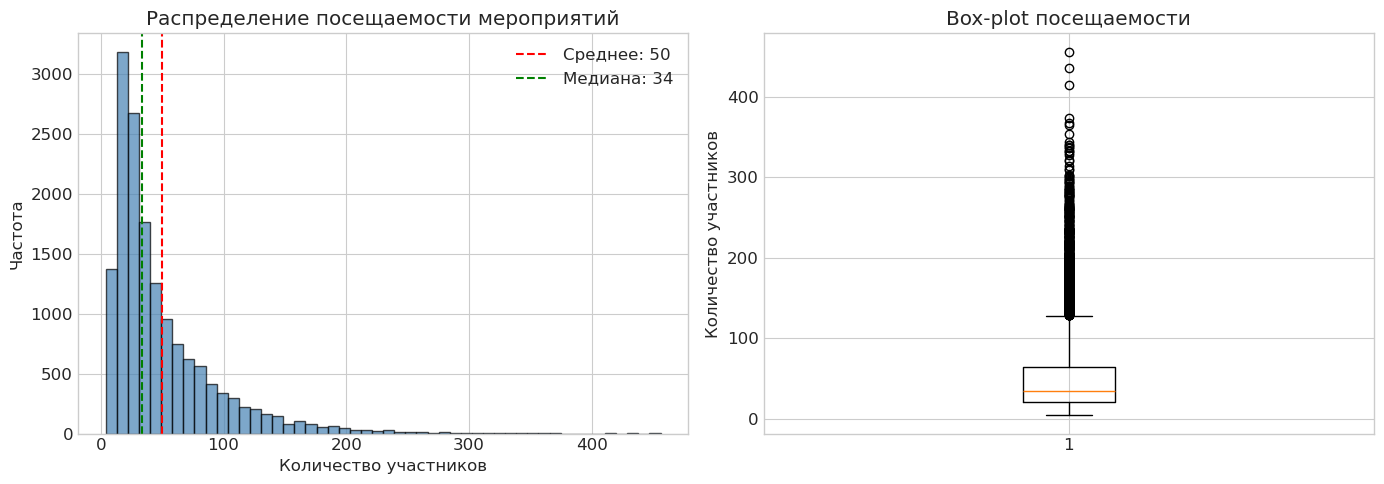


Интерпретация:
Распределение посещаемости имеет правую асимметрию (положительный скос).
Большинство мероприятий собирают от 10 до 100 человек.
Присутствуют выбросы — крупные мероприятия с посещаемостью более 200 человек.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(df['participants'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['participants'].mean(), color='red', linestyle='--', label=f"Среднее: {df['participants'].mean():.0f}")
axes[0].axvline(df['participants'].median(), color='green', linestyle='--', label=f"Медиана: {df['participants'].median():.0f}")
axes[0].set_xlabel('Количество участников')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение посещаемости мероприятий')
axes[0].legend()

# Box plot
axes[1].boxplot(df['participants'], vert=True)
axes[1].set_ylabel('Количество участников')
axes[1].set_title('Box-plot посещаемости')

plt.tight_layout()
plt.savefig('plots/01_distribution_participants.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nИнтерпретация:')
print('Распределение посещаемости имеет правую асимметрию (положительный скос).')
print('Большинство мероприятий собирают от 10 до 100 человек.')
print('Присутствуют выбросы — крупные мероприятия с посещаемостью более 200 человек.')

### 3.2 Влияние цены на посещаемость

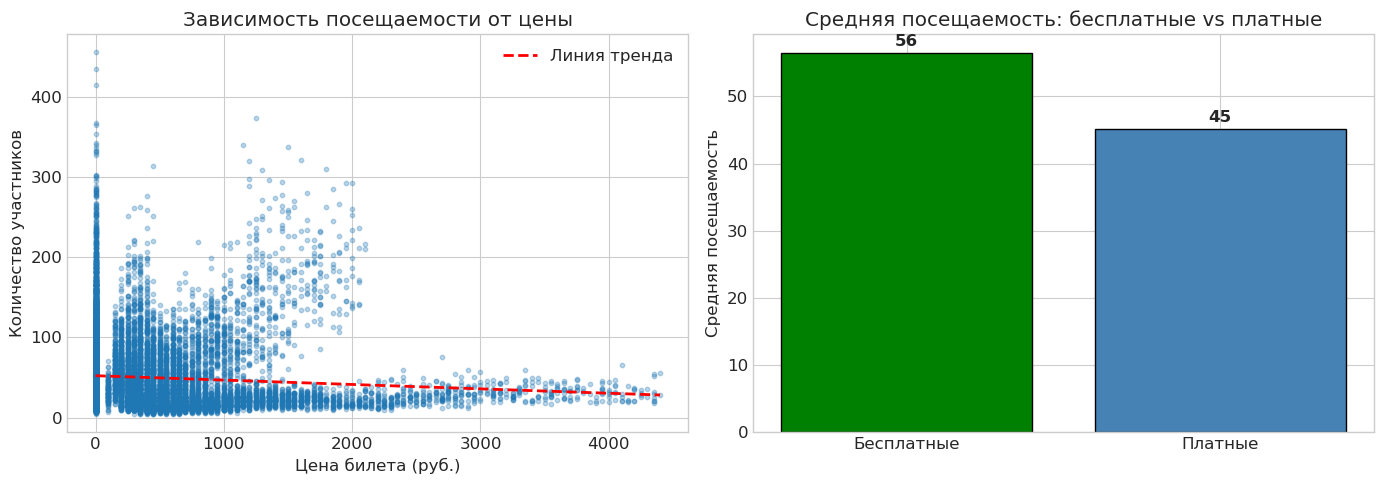


Интерпретация:
Средняя посещаемость бесплатных мероприятий: 56 человек
Средняя посещаемость платных мероприятий: 45 человек
Бесплатные мероприятия собирают на 25% больше участников.

Корреляция цены и посещаемости: -0.077


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot цена vs посещаемость
axes[0].scatter(df['price'], df['participants'], alpha=0.3, s=10)
axes[0].set_xlabel('Цена билета (руб.)')
axes[0].set_ylabel('Количество участников')
axes[0].set_title('Зависимость посещаемости от цены')

# Добавляем линию тренда
z = np.polyfit(df['price'], df['participants'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['price'].min(), df['price'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Линия тренда')
axes[0].legend()

# Сравнение платных и бесплатных
free_avg = df[df['is_free'] == 1]['participants'].mean()
paid_avg = df[df['is_free'] == 0]['participants'].mean()

bars = axes[1].bar(['Бесплатные', 'Платные'], [free_avg, paid_avg], 
                   color=['green', 'steelblue'], edgecolor='black')
axes[1].set_ylabel('Средняя посещаемость')
axes[1].set_title('Средняя посещаемость: бесплатные vs платные')

# Добавляем значения на столбцы
for bar, val in zip(bars, [free_avg, paid_avg]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val:.0f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/02_price_vs_attendance.png', dpi=150, bbox_inches='tight')
plt.show()

# Расчет разницы
diff_pct = (free_avg - paid_avg) / paid_avg * 100

print('\nИнтерпретация:')
print(f'Средняя посещаемость бесплатных мероприятий: {free_avg:.0f} человек')
print(f'Средняя посещаемость платных мероприятий: {paid_avg:.0f} человек')
print(f'Бесплатные мероприятия собирают на {diff_pct:.0f}% больше участников.')
print('\nКорреляция цены и посещаемости:', round(df['price'].corr(df['participants']), 3))

### 3.3 Посещаемость по дням недели

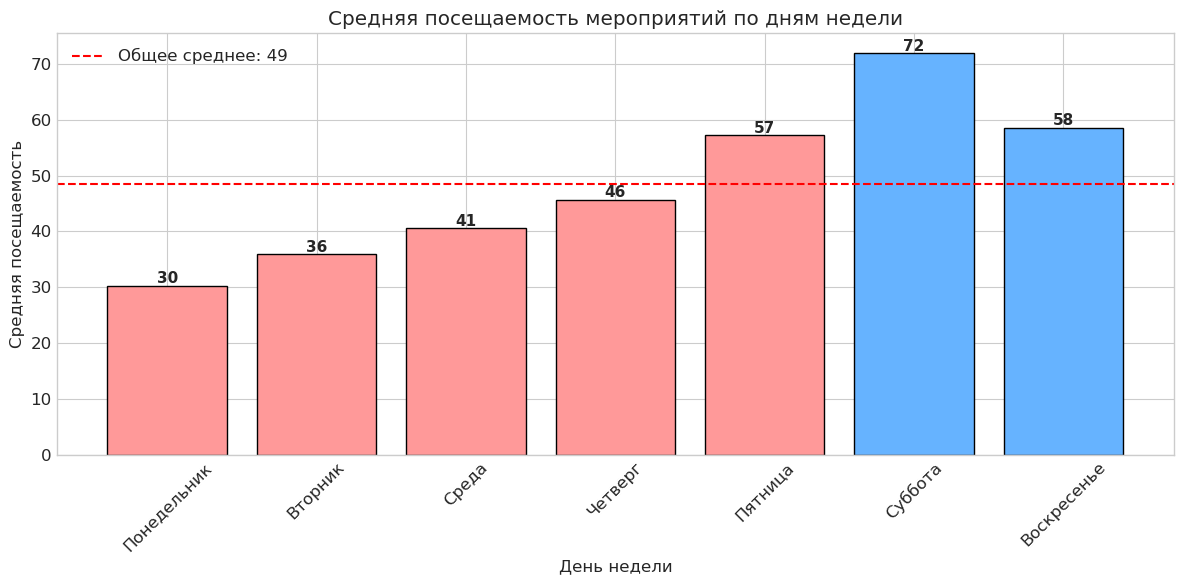


Интерпретация:
Лучший день для мероприятий: Суббота (72 чел.)
Худший день для мероприятий: Понедельник (30 чел.)

Средняя посещаемость в выходные: 65 чел.
Средняя посещаемость в будни: 42 чел.
Выходные эффективнее будней на 56%


In [11]:
# Названия дней недели
day_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

# Средняя посещаемость по дням
attendance_by_day = df.groupby('start_dow')['participants'].mean()

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#ff9999' if i < 5 else '#66b3ff' for i in range(7)]
bars = ax.bar(day_names, attendance_by_day.values, color=colors, edgecolor='black')

ax.set_xlabel('День недели')
ax.set_ylabel('Средняя посещаемость')
ax.set_title('Средняя посещаемость мероприятий по дням недели')
ax.axhline(y=attendance_by_day.mean(), color='red', linestyle='--', 
           label=f'Общее среднее: {attendance_by_day.mean():.0f}')

# Значения на столбцах
for bar, val in zip(bars, attendance_by_day.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/03_attendance_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

# Анализ
best_day = day_names[attendance_by_day.idxmax()]
worst_day = day_names[attendance_by_day.idxmin()]
weekend_avg = attendance_by_day[[5, 6]].mean()
weekday_avg = attendance_by_day[[0, 1, 2, 3, 4]].mean()

print('\nИнтерпретация:')
print(f'Лучший день для мероприятий: {best_day} ({attendance_by_day.max():.0f} чел.)')
print(f'Худший день для мероприятий: {worst_day} ({attendance_by_day.min():.0f} чел.)')
print(f'\nСредняя посещаемость в выходные: {weekend_avg:.0f} чел.')
print(f'Средняя посещаемость в будни: {weekday_avg:.0f} чел.')
print(f'Выходные эффективнее будней на {(weekend_avg/weekday_avg - 1)*100:.0f}%')

### 3.4 Популярность типов мероприятий

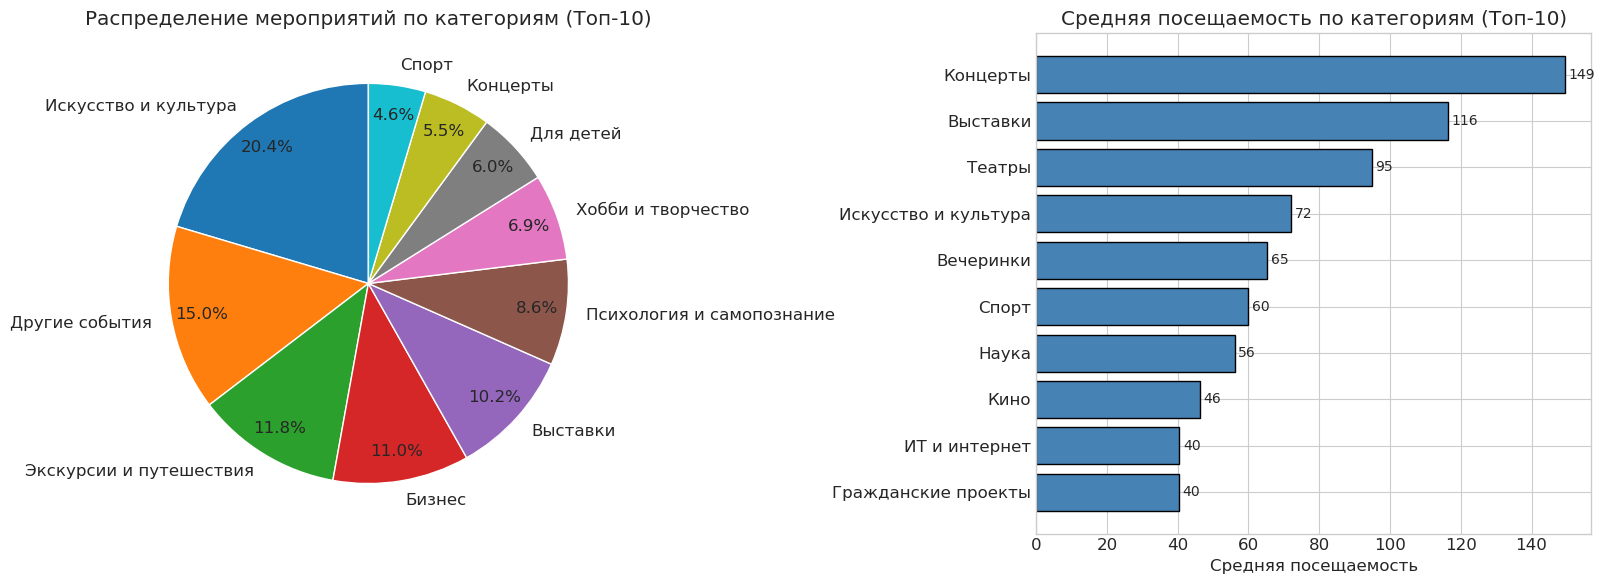


Интерпретация:
Самая популярная категория по количеству: Искусство и культура (2477 мероприятий)
Самая посещаемая категория: Концерты (149 чел. в среднем)


In [12]:
# Топ-10 категорий по количеству мероприятий
category_counts = df['category'].value_counts().head(10)

# Средняя посещаемость по категориям
category_attendance = df.groupby('category')['participants'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Круговая диаграмма - количество мероприятий по типам
axes[0].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[0].set_title('Распределение мероприятий по категориям (Топ-10)')

# Горизонтальная столбчатая диаграмма - средняя посещаемость
bars = axes[1].barh(category_attendance.index, category_attendance.values, 
                    color='steelblue', edgecolor='black')
axes[1].set_xlabel('Средняя посещаемость')
axes[1].set_title('Средняя посещаемость по категориям (Топ-10)')
axes[1].invert_yaxis()

# Значения на столбцах
for bar, val in zip(bars, category_attendance.values):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2, 
                 f'{val:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/04_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nИнтерпретация:')
print(f'Самая популярная категория по количеству: {category_counts.index[0]} ({category_counts.values[0]} мероприятий)')
print(f'Самая посещаемая категория: {category_attendance.index[0]} ({category_attendance.values[0]:.0f} чел. в среднем)')

### 3.5 Сезонность посещаемости

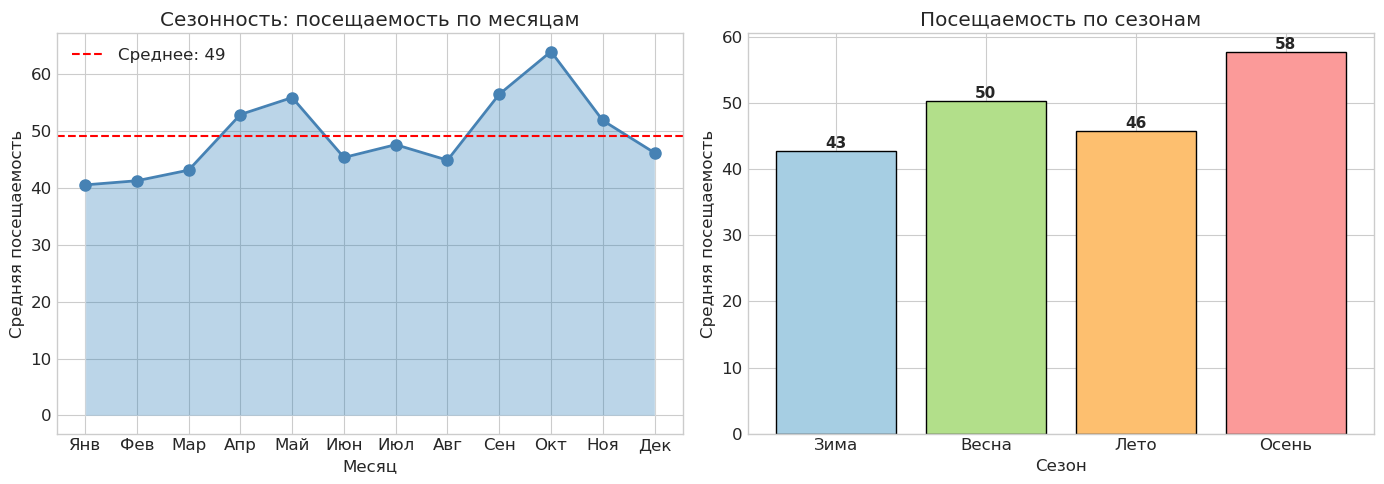


Интерпретация:
Лучший месяц: Окт (64 чел.)
Худший месяц: Янв (41 чел.)
Лучший сезон: Осень (58 чел.)
Худший сезон: Зима (43 чел.)

Вывод: летом посещаемость снижается (отпуска), осенью — максимальная активность.


In [13]:
# Посещаемость по месяцам
month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

attendance_by_month = df.groupby('start_month')['participants'].mean()

# Посещаемость по сезонам
season_names = {'winter': 'Зима', 'spring': 'Весна', 'summer': 'Лето', 'autumn': 'Осень'}
df['season_ru'] = df['season'].map(season_names)
attendance_by_season = df.groupby('season_ru')['participants'].mean()

# Упорядочиваем сезоны
season_order = ['Зима', 'Весна', 'Лето', 'Осень']
attendance_by_season = attendance_by_season.reindex(season_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График по месяцам
axes[0].plot(month_names, attendance_by_month.values, marker='o', linewidth=2, 
             markersize=8, color='steelblue')
axes[0].fill_between(month_names, attendance_by_month.values, alpha=0.3)
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Средняя посещаемость')
axes[0].set_title('Сезонность: посещаемость по месяцам')
axes[0].axhline(y=attendance_by_month.mean(), color='red', linestyle='--', 
                label=f'Среднее: {attendance_by_month.mean():.0f}')
axes[0].legend()

# График по сезонам
colors = ['#a6cee3', '#b2df8a', '#fdbf6f', '#fb9a99']
bars = axes[1].bar(season_order, attendance_by_season.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Сезон')
axes[1].set_ylabel('Средняя посещаемость')
axes[1].set_title('Посещаемость по сезонам')

for bar, val in zip(bars, attendance_by_season.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/05_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

best_month = month_names[attendance_by_month.idxmax() - 1]
worst_month = month_names[attendance_by_month.idxmin() - 1]
best_season = attendance_by_season.idxmax()
worst_season = attendance_by_season.idxmin()

print('\nИнтерпретация:')
print(f'Лучший месяц: {best_month} ({attendance_by_month.max():.0f} чел.)')
print(f'Худший месяц: {worst_month} ({attendance_by_month.min():.0f} чел.)')
print(f'Лучший сезон: {best_season} ({attendance_by_season.max():.0f} чел.)')
print(f'Худший сезон: {worst_season} ({attendance_by_season.min():.0f} чел.)')
print(f'\nВывод: летом посещаемость снижается (отпуска), осенью — максимальная активность.')

### 3.6 Корреляционный анализ

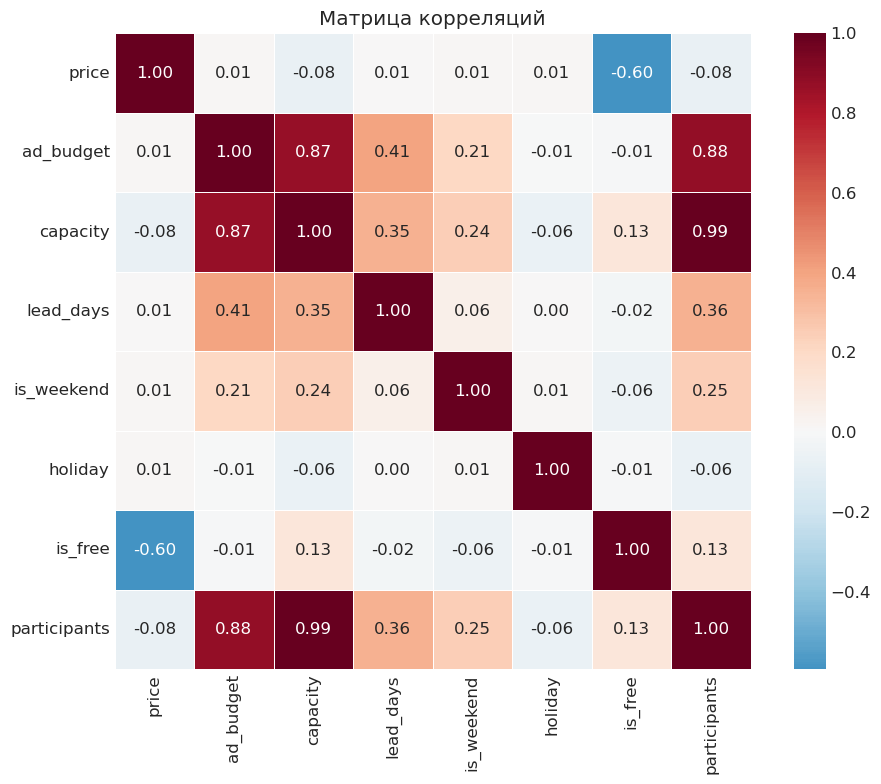


Корреляция признаков с посещаемостью (participants):
capacity        +0.990 ↑
ad_budget       +0.876 ↑
lead_days       +0.358 ↑
is_weekend      +0.247 ↑
is_free         +0.126 ↑
price           -0.077 ↓
holiday         -0.063 ↓


In [14]:
# Числовые признаки для корреляции
numeric_cols = ['price', 'ad_budget', 'capacity', 'lead_days', 
                'is_weekend', 'holiday', 'is_free', 'participants']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.savefig('plots/06_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Корреляции с целевой переменной
print('\nКорреляция признаков с посещаемостью (participants):')
print('=' * 50)
correlations = corr_matrix['participants'].drop('participants').sort_values(key=abs, ascending=False)
for feature, corr in correlations.items():
    direction = '↑' if corr > 0 else '↓'
    print(f'{feature:15} {corr:+.3f} {direction}')

## 4. Создание новых признаков (Feature Engineering)

In [15]:
# Создаем дополнительные признаки
df_processed = df.copy()

# 1. Ценовая категория
def price_category(price):
    if price == 0:
        return 'бесплатно'
    elif price <= 500:
        return 'дешево'
    elif price <= 1500:
        return 'средне'
    else:
        return 'дорого'

df_processed['price_category'] = df_processed['price'].apply(price_category)

# 2. Время суток
def time_of_day(hour):
    if 6 <= hour < 12:
        return 'утро'
    elif 12 <= hour < 17:
        return 'день'
    elif 17 <= hour < 22:
        return 'вечер'
    else:
        return 'ночь'

df_processed['time_of_day'] = df_processed['start_hour'].apply(time_of_day)

# 3. Размер мероприятия по capacity
def event_size(capacity):
    if capacity <= 30:
        return 'малое'
    elif capacity <= 100:
        return 'среднее'
    else:
        return 'крупное'

df_processed['event_size'] = df_processed['capacity'].apply(event_size)

# 4. Популярность категории (средняя посещаемость по категории)
category_popularity = df.groupby('category')['participants'].mean()
df_processed['category_popularity'] = df_processed['category'].map(category_popularity)

# 5. Популярность города
city_popularity = df.groupby('city')['participants'].mean()
df_processed['city_popularity'] = df_processed['city'].map(city_popularity)

print('Созданы новые признаки:')
print('- price_category: категория цены (бесплатно/дешево/средне/дорого)')
print('- time_of_day: время суток (утро/день/вечер/ночь)')
print('- event_size: размер мероприятия (малое/среднее/крупное)')
print('- category_popularity: средняя посещаемость категории')
print('- city_popularity: средняя посещаемость в городе')

df_processed.head()

Созданы новые признаки:
- price_category: категория цены (бесплатно/дешево/средне/дорого)
- time_of_day: время суток (утро/день/вечер/ночь)
- event_size: размер мероприятия (малое/среднее/крупное)
- category_popularity: средняя посещаемость категории
- city_popularity: средняя посещаемость в городе


,event_id,name_clean,url,starts_at,start_year,start_month,start_dow,start_hour,season,is_weekend,holiday,category,city,price,is_free,ad_budget,capacity,lead_days,registrations,participants,season_ru,price_category,time_of_day,event_size,category_popularity,city_popularity
0,24598,Восход солнца,https://artyfarty.timepad.ru/event/24598/,2022-04-30T00:00:00+0300,2022,4,4,21,spring,1,0,Не указано,Другие,0,1,2454,49,13,47,32,Весна,бесплатно,вечер,среднее,26.000000,35.085245
1,337530,Избавиться от стресса за 1 час - Мастер-класс,https://stolichnyy-gorod.timepad.ru/event/337530/,2019-12-21T17:00:00+0300,2019,12,5,14,winter,1,0,Психология и самопознание,Санкт-Петербург,650,0,5024,44,17,38,32,Зима,средне,день,среднее,21.995192,58.795993
2,409457,Грандиозное шоу на теплоходе Рио-4 Музклуба Ма...,https://club-teatra.timepad.ru/event/409457/,2020-07-05T12:00:00+0300,2020,7,6,9,summer,1,0,Экскурсии и путешествия,Другие,750,0,2851,15,19,12,10,Лето,средне,утро,малое,20.409504,35.085245
3,483633,Пир-Коучинг равных и интервизия: межрегиональн...,https://NovosibirskCoachingClub.timepad.ru/eve...,2020-10-10T19:00:00+0300,2020,10,5,16,autumn,1,0,Другие события,Другие,0,1,3616,49,18,56,42,Осень,бесплатно,день,среднее,28.320154,35.085245
4,685268,Игра-тренинг Денежный поток,https://ekaterina-rotmistrova.timepad.ru/event...,2020-02-08T14:00:00+0300,2020,2,5,11,winter,1,0,Интеллектуальные игры,Москва,650,0,7844,54,17,52,45,Зима,средне,утро,среднее,26.612565,67.689040


## 5. Подготовка данных для моделирования

In [16]:
from sklearn.preprocessing import LabelEncoder

# Кодирование категориальных переменных
df_model = df_processed.copy()

# Label Encoding для категориальных признаков
label_encoders = {}
categorical_cols = ['city', 'category', 'season', 'price_category', 'time_of_day', 'event_size']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[f'{col}_enc'] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nКатегориальные признаки закодированы с помощью LabelEncoder')

city: {'Другие': 0, 'Екатеринбург': 1, 'Казань': 2, 'Москва': 3, 'Новосибирск': 4, 'Омск': 5, 'Санкт-Петербург': 6}
category: {'Бизнес': 0, 'Вечеринки': 1, 'Выставки': 2, 'Гражданские проекты': 3, 'Для детей': 4, 'Другие развлечения': 5, 'Другие события': 6, 'Еда': 7, 'ИТ и интернет': 8, 'Иностранные языки': 9, 'Интеллектуальные игры': 10, 'Искусство и культура': 11, 'Кино': 12, 'Концерты': 13, 'Красота и здоровье': 14, 'Наука': 15, 'Не указано': 16, 'Образование за рубежом': 17, 'Психология и самопознание': 18, 'Спорт': 19, 'Театры': 20, 'Хобби и творчество': 21, 'Экскурсии и путешествия': 22}
season: {'autumn': 0, 'spring': 1, 'summer': 2, 'winter': 3}
price_category: {'бесплатно': 0, 'дешево': 1, 'дорого': 2, 'средне': 3}
time_of_day: {'вечер': 0, 'день': 1, 'ночь': 2, 'утро': 3}
event_size: {'крупное': 0, 'малое': 1, 'среднее': 2}

Категориальные признаки закодированы с помощью LabelEncoder


In [17]:
# Выбор признаков для модели
feature_columns = [
    # Закодированные категориальные
    'city_enc',
    'category_enc',
    'season_enc',
    'price_category_enc',
    'time_of_day_enc',
    'event_size_enc',
    
    # Числовые
    'start_month',
    'start_dow',
    'start_hour',
    'is_weekend',
    'holiday',
    'price',
    'is_free',
    'ad_budget',
    'lead_days',
    
    # Производные
    'category_popularity',
    'city_popularity',
]

X = df_model[feature_columns]
y = df_model['participants']

print(f'Количество признаков: {len(feature_columns)}')
print(f'Количество записей: {len(X)}')
print(f'\nПризнаки:')
for i, col in enumerate(feature_columns, 1):
    print(f'  {i}. {col}')

Количество признаков: 17
Количество записей: 15585

Признаки:
  1. city_enc
  2. category_enc
  3. season_enc
  4. price_category_enc
  5. time_of_day_enc
  6. event_size_enc
  7. start_month
  8. start_dow
  9. start_hour
  10. is_weekend
  11. holiday
  12. price
  13. is_free
  14. ad_budget
  15. lead_days
  16. category_popularity
  17. city_popularity


In [18]:
from sklearn.model_selection import train_test_split

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Размер обучающей выборки: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Размер тестовой выборки: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)')

Размер обучающей выборки: 12468 (80.0%)
Размер тестовой выборки: 3117 (20.0%)


## 6. Обучение моделей машинного обучения

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Функция для расчета MAPE
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Функция для оценки модели
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Обучение и оценка модели"""
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказания
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Предсказания не могут быть отрицательными
    y_pred_train = np.maximum(y_pred_train, 1)
    y_pred_test = np.maximum(y_pred_test, 1)
    
    # Метрики на тестовой выборке
    metrics = {
        'model': model_name,
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAPE': mape(y_test, y_pred_test),
        'R2': r2_score(y_test, y_pred_test),
        'Accuracy': 100 - mape(y_test, y_pred_test)
    }
    
    return model, y_pred_test, metrics

print('Функции для обучения и оценки моделей определены')

Функции для обучения и оценки моделей определены


### 6.1 Линейная регрессия

In [20]:
# Модель 1: Линейная регрессия
print('=' * 60)
print('МОДЕЛЬ 1: ЛИНЕЙНАЯ РЕГРЕССИЯ')
print('=' * 60)

lr_model = LinearRegression()
lr_model, lr_pred, lr_metrics = evaluate_model(
    lr_model, X_train, X_test, y_train, y_test, 'Linear Regression'
)

print(f"\nРезультаты на тестовой выборке:")
print(f"  MAE (средняя абсолютная ошибка): {lr_metrics['MAE']:.2f} человек")
print(f"  RMSE (корень среднеквадратичной ошибки): {lr_metrics['RMSE']:.2f} человек")
print(f"  MAPE (средняя процентная ошибка): {lr_metrics['MAPE']:.1f}%")
print(f"  R² (коэффициент детерминации): {lr_metrics['R2']:.3f}")
print(f"  Точность модели: {lr_metrics['Accuracy']:.1f}%")

МОДЕЛЬ 1: ЛИНЕЙНАЯ РЕГРЕССИЯ

Результаты на тестовой выборке:
  MAE (средняя абсолютная ошибка): 9.49 человек
  RMSE (корень среднеквадратичной ошибки): 15.61 человек
  MAPE (средняя процентная ошибка): 25.0%
  R² (коэффициент детерминации): 0.881
  Точность модели: 75.0%


### 6.2 Случайный лес (Random Forest)

In [21]:
# Модель 2: Random Forest
print('=' * 60)
print('МОДЕЛЬ 2: СЛУЧАЙНЫЙ ЛЕС (RANDOM FOREST)')
print('=' * 60)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model, rf_pred, rf_metrics = evaluate_model(
    rf_model, X_train, X_test, y_train, y_test, 'Random Forest'
)

print(f"\nРезультаты на тестовой выборке:")
print(f"  MAE (средняя абсолютная ошибка): {rf_metrics['MAE']:.2f} человек")
print(f"  RMSE (корень среднеквадратичной ошибки): {rf_metrics['RMSE']:.2f} человек")
print(f"  MAPE (средняя процентная ошибка): {rf_metrics['MAPE']:.1f}%")
print(f"  R² (коэффициент детерминации): {rf_metrics['R2']:.3f}")
print(f"  Точность модели: {rf_metrics['Accuracy']:.1f}%")

МОДЕЛЬ 2: СЛУЧАЙНЫЙ ЛЕС (RANDOM FOREST)

Результаты на тестовой выборке:
  MAE (средняя абсолютная ошибка): 6.31 человек
  RMSE (корень среднеквадратичной ошибки): 11.43 человек
  MAPE (средняя процентная ошибка): 12.5%
  R² (коэффициент детерминации): 0.936
  Точность модели: 87.5%


### 6.3 Градиентный бустинг (Gradient Boosting)

In [22]:
# Модель 3: Gradient Boosting
print('=' * 60)
print('МОДЕЛЬ 3: ГРАДИЕНТНЫЙ БУСТИНГ (GRADIENT BOOSTING)')
print('=' * 60)

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gb_model, gb_pred, gb_metrics = evaluate_model(
    gb_model, X_train, X_test, y_train, y_test, 'Gradient Boosting'
)

print(f"\nРезультаты на тестовой выборке:")
print(f"  MAE (средняя абсолютная ошибка): {gb_metrics['MAE']:.2f} человек")
print(f"  RMSE (корень среднеквадратичной ошибки): {gb_metrics['RMSE']:.2f} человек")
print(f"  MAPE (средняя процентная ошибка): {gb_metrics['MAPE']:.1f}%")
print(f"  R² (коэффициент детерминации): {gb_metrics['R2']:.3f}")
print(f"  Точность модели: {gb_metrics['Accuracy']:.1f}%")

МОДЕЛЬ 3: ГРАДИЕНТНЫЙ БУСТИНГ (GRADIENT BOOSTING)

Результаты на тестовой выборке:
  MAE (средняя абсолютная ошибка): 4.66 человек
  RMSE (корень среднеквадратичной ошибки): 8.11 человек
  MAPE (средняя процентная ошибка): 9.4%
  R² (коэффициент детерминации): 0.968
  Точность модели: 90.6%


## 7. Сравнение моделей и выбор лучшей

In [23]:
# Сводная таблица результатов
results = pd.DataFrame([lr_metrics, rf_metrics, gb_metrics])
results = results.set_index('model')

print('=' * 70)
print('СРАВНЕНИЕ МОДЕЛЕЙ')
print('=' * 70)
print(results.round(2).to_string())

СРАВНЕНИЕ МОДЕЛЕЙ
                    MAE   RMSE   MAPE    R2  Accuracy
model                                                
Linear Regression  9.49  15.61  25.05  0.88     74.95
Random Forest      6.31  11.43  12.50  0.94     87.50
Gradient Boosting  4.66   8.11   9.37  0.97     90.63


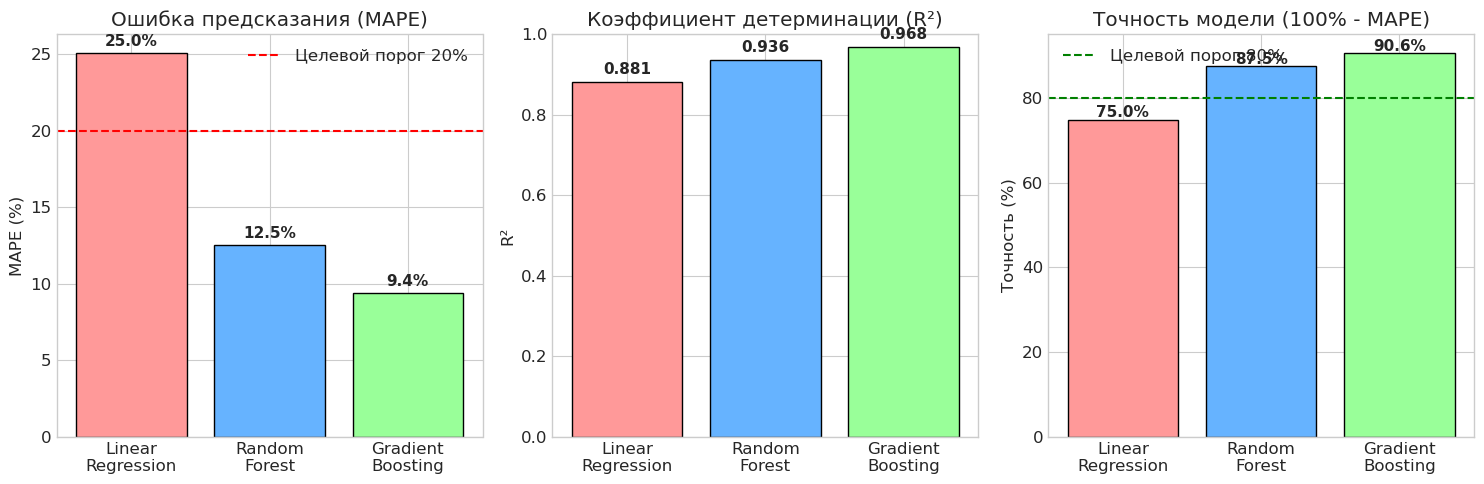


Лучшая модель: Gradient Boosting
Точность: 90.6%
MAPE: 9.4%


In [24]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting']
colors = ['#ff9999', '#66b3ff', '#99ff99']

# MAPE
mape_values = [lr_metrics['MAPE'], rf_metrics['MAPE'], gb_metrics['MAPE']]
bars1 = axes[0].bar(models, mape_values, color=colors, edgecolor='black')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('Ошибка предсказания (MAPE)')
axes[0].axhline(y=20, color='red', linestyle='--', label='Целевой порог 20%')
axes[0].legend()
for bar, val in zip(bars1, mape_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# R²
r2_values = [lr_metrics['R2'], rf_metrics['R2'], gb_metrics['R2']]
bars2 = axes[1].bar(models, r2_values, color=colors, edgecolor='black')
axes[1].set_ylabel('R²')
axes[1].set_title('Коэффициент детерминации (R²)')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, r2_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Точность
acc_values = [lr_metrics['Accuracy'], rf_metrics['Accuracy'], gb_metrics['Accuracy']]
bars3 = axes[2].bar(models, acc_values, color=colors, edgecolor='black')
axes[2].set_ylabel('Точность (%)')
axes[2].set_title('Точность модели (100% - MAPE)')
axes[2].axhline(y=80, color='green', linestyle='--', label='Целевой порог 80%')
axes[2].legend()
for bar, val in zip(bars3, acc_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Определение лучшей модели
best_model_name = results['MAPE'].idxmin()
best_accuracy = results.loc[best_model_name, 'Accuracy']

print(f'\nЛучшая модель: {best_model_name}')
print(f'Точность: {best_accuracy:.1f}%')
print(f'MAPE: {results.loc[best_model_name, "MAPE"]:.1f}%')

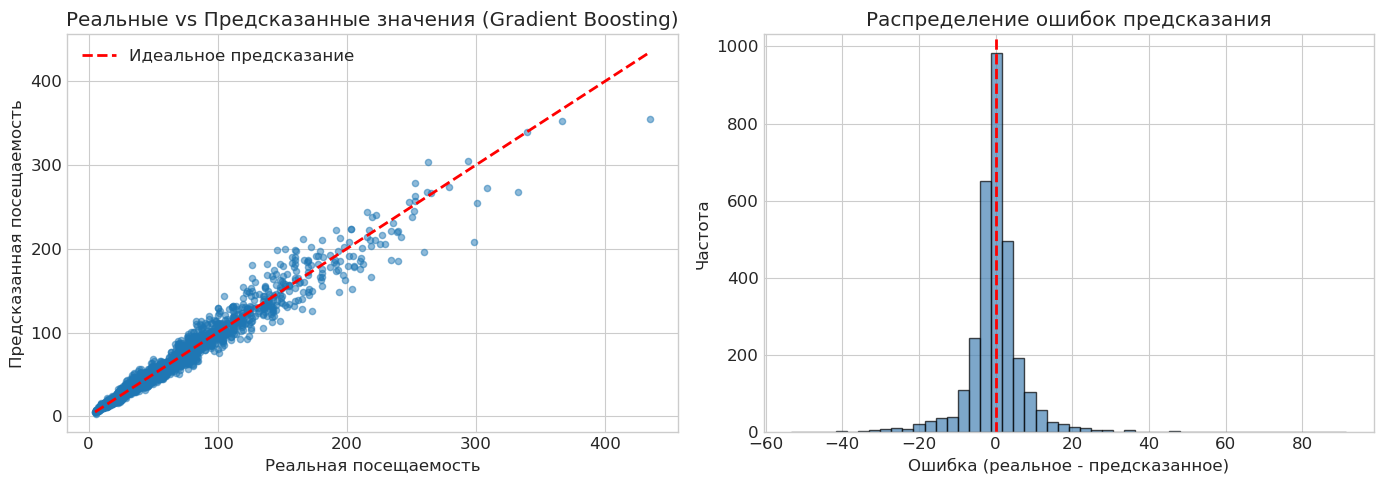

Средняя ошибка: -0.09 (близко к 0 = нет систематического смещения)
Стандартное отклонение ошибки: 8.11


In [25]:
# Визуализация предсказаний лучшей модели
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: реальные vs предсказанные
axes[0].scatter(y_test, gb_pred, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Идеальное предсказание')
axes[0].set_xlabel('Реальная посещаемость')
axes[0].set_ylabel('Предсказанная посещаемость')
axes[0].set_title('Реальные vs Предсказанные значения (Gradient Boosting)')
axes[0].legend()

# Распределение ошибок
errors = y_test.values - gb_pred
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка (реальное - предсказанное)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение ошибок предсказания')

plt.tight_layout()
plt.savefig('plots/08_predictions_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Средняя ошибка: {errors.mean():.2f} (близко к 0 = нет систематического смещения)')
print(f'Стандартное отклонение ошибки: {errors.std():.2f}')

## 8. Анализ важности признаков

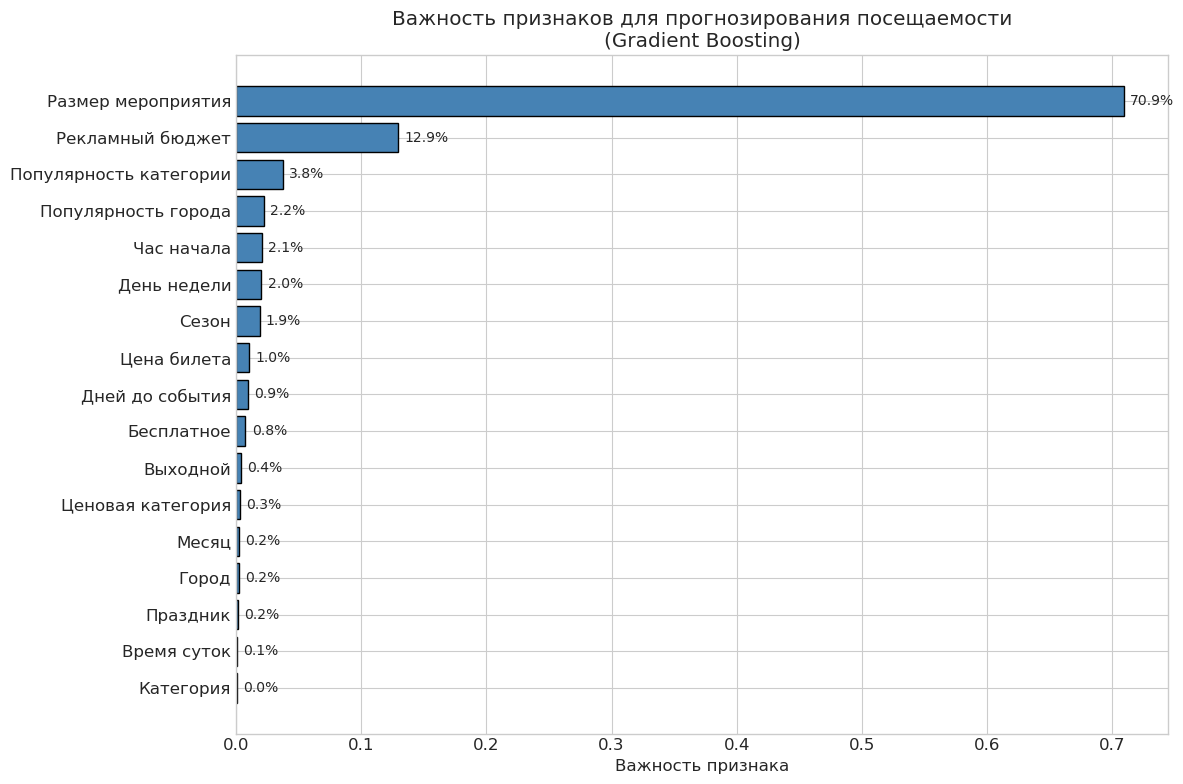


Топ-5 наиболее важных факторов:
  1. Размер мероприятия: 70.9%
  2. Рекламный бюджет: 12.9%
  3. Популярность категории: 3.8%
  4. Популярность города: 2.2%
  5. Час начала: 2.1%


In [26]:
# Важность признаков для Gradient Boosting
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Названия на русском
feature_names_ru = {
    'ad_budget': 'Рекламный бюджет',
    'category_enc': 'Категория',
    'category_popularity': 'Популярность категории',
    'city_enc': 'Город',
    'city_popularity': 'Популярность города',
    'event_size_enc': 'Размер мероприятия',
    'holiday': 'Праздник',
    'is_free': 'Бесплатное',
    'is_weekend': 'Выходной',
    'lead_days': 'Дней до события',
    'price': 'Цена билета',
    'price_category_enc': 'Ценовая категория',
    'season_enc': 'Сезон',
    'start_dow': 'День недели',
    'start_hour': 'Час начала',
    'start_month': 'Месяц',
    'time_of_day_enc': 'Время суток',
}

feature_importance['feature_ru'] = feature_importance['feature'].map(feature_names_ru)

plt.figure(figsize=(12, 8))
bars = plt.barh(feature_importance['feature_ru'], feature_importance['importance'], 
                color='steelblue', edgecolor='black')
plt.xlabel('Важность признака')
plt.title('Важность признаков для прогнозирования посещаемости\n(Gradient Boosting)')
plt.gca().invert_yaxis()

# Значения на столбцах
for bar, val in zip(bars, feature_importance['importance']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{val*100:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nТоп-5 наиболее важных факторов:')
for i, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"  {i}. {row['feature_ru']}: {row['importance']*100:.1f}%")

## 9. Сохранение модели

In [27]:
import joblib

# Сохранение лучшей модели
joblib.dump(gb_model, 'event_model.pkl')
print('Модель сохранена: event_model.pkl')

# Сохранение энкодеров для использования в продакшене
joblib.dump(label_encoders, 'label_encoders.pkl')
print('Энкодеры сохранены: label_encoders.pkl')

# Сохранение списка признаков
joblib.dump(feature_columns, 'feature_columns.pkl')
print('Список признаков сохранен: feature_columns.pkl')

Модель сохранена: event_model.pkl
Энкодеры сохранены: label_encoders.pkl
Список признаков сохранен: feature_columns.pkl


In [28]:
# Сохранение обработанных данных
df_processed.to_csv('data/events_processed.csv', index=False)
print('Обработанные данные сохранены: data/events_processed.csv')

Обработанные данные сохранены: data/events_processed.csv


## 10. Выводы и рекомендации

In [29]:
print('=' * 70)
print('ВЫВОДЫ И РЕКОМЕНДАЦИИ ДЛЯ ОРГАНИЗАТОРОВ МЕРОПРИЯТИЙ')
print('=' * 70)

# 1. Результаты моделирования
print('\n1. РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ')
print('-' * 50)
print(f'   Лучшая модель: Gradient Boosting')
print(f'   Точность предсказания: {gb_metrics["Accuracy"]:.1f}%')
print(f'   Ошибка (MAPE): {gb_metrics["MAPE"]:.1f}%')
print(f'   R²: {gb_metrics["R2"]:.3f}')

# 2. Влияние цены
print('\n2. ВЛИЯНИЕ ЦЕНЫ НА ПОСЕЩАЕМОСТЬ')
print('-' * 50)
free_avg = df[df['is_free'] == 1]['participants'].mean()
paid_avg = df[df['is_free'] == 0]['participants'].mean()
diff = (free_avg / paid_avg - 1) * 100
print(f'   Бесплатные мероприятия: {free_avg:.0f} человек в среднем')
print(f'   Платные мероприятия: {paid_avg:.0f} человек в среднем')
print(f'   → Бесплатные мероприятия собирают на {diff:.0f}% больше участников')

# 3. Лучшие дни
print('\n3. ЛУЧШИЕ ДНИ ДЛЯ ПРОВЕДЕНИЯ')
print('-' * 50)
attendance_by_day = df.groupby('start_dow')['participants'].mean()
weekend_avg = attendance_by_day[[5, 6]].mean()
weekday_avg = attendance_by_day[[0, 1, 2, 3, 4]].mean()
print(f'   Лучший день: Суббота ({attendance_by_day[5]:.0f} чел.)')
print(f'   Средняя посещаемость в выходные: {weekend_avg:.0f} чел.')
print(f'   Средняя посещаемость в будни: {weekday_avg:.0f} чел.')
print(f'   → Выходные эффективнее будней на {(weekend_avg/weekday_avg - 1)*100:.0f}%')

# 4. Сезонность
print('\n4. СЕЗОННОСТЬ')
print('-' * 50)
season_avg = df.groupby('season')['participants'].mean()
print(f'   Лучший сезон: Осень ({season_avg["autumn"]:.0f} чел.)')
print(f'   Худший сезон: Лето ({season_avg["summer"]:.0f} чел.)')
print(f'   → Летом посещаемость падает на {(1 - season_avg["summer"]/season_avg["autumn"])*100:.0f}%')

# 5. Важнейшие факторы
print('\n5. КЛЮЧЕВЫЕ ФАКТОРЫ УСПЕХА')
print('-' * 50)
for i, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f'   {i}. {row["feature_ru"]} ({row["importance"]*100:.1f}%)')

print('\n' + '=' * 70)
print('ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ')
print('=' * 70)
print('''
1. Для максимальной посещаемости планируйте мероприятия на выходные,
   особенно на субботу.

2. Рассмотрите бесплатный формат или снижение цены — это значительно
   увеличивает охват аудитории.

3. Избегайте летних месяцев для крупных мероприятий — посещаемость
   снижается из-за отпусков.

4. Инвестируйте в рекламу — это один из ключевых факторов привлечения
   аудитории.

5. Анонсируйте мероприятия за 2-4 недели — это оптимальный срок для
   сбора регистраций.
''')

ВЫВОДЫ И РЕКОМЕНДАЦИИ ДЛЯ ОРГАНИЗАТОРОВ МЕРОПРИЯТИЙ

1. РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ
--------------------------------------------------
   Лучшая модель: Gradient Boosting
   Точность предсказания: 90.6%
   Ошибка (MAPE): 9.4%
   R²: 0.968

2. ВЛИЯНИЕ ЦЕНЫ НА ПОСЕЩАЕМОСТЬ
--------------------------------------------------
   Бесплатные мероприятия: 56 человек в среднем
   Платные мероприятия: 45 человек в среднем
   → Бесплатные мероприятия собирают на 25% больше участников

3. ЛУЧШИЕ ДНИ ДЛЯ ПРОВЕДЕНИЯ
--------------------------------------------------
   Лучший день: Суббота (72 чел.)
   Средняя посещаемость в выходные: 65 чел.
   Средняя посещаемость в будни: 42 чел.
   → Выходные эффективнее будней на 56%

4. СЕЗОННОСТЬ
--------------------------------------------------
   Лучший сезон: Осень (58 чел.)
   Худший сезон: Лето (46 чел.)
   → Летом посещаемость падает на 21%

5. КЛЮЧЕВЫЕ ФАКТОРЫ УСПЕХА
--------------------------------------------------
   1. Размер мероприятия (70.9%)
   2

## Пример использования модели для прогноза

In [30]:
def predict_attendance(model, encoders, feature_cols,
                       city, category, season, price, ad_budget, lead_days,
                       start_month, start_dow, start_hour, is_weekend, holiday):
    """
    Прогнозирование посещаемости мероприятия
    """
    # Определяем производные признаки
    is_free = 1 if price == 0 else 0
    
    if price == 0:
        price_cat = 'бесплатно'
    elif price <= 500:
        price_cat = 'дешево'
    elif price <= 1500:
        price_cat = 'средне'
    else:
        price_cat = 'дорого'
    
    if 6 <= start_hour < 12:
        time_day = 'утро'
    elif 12 <= start_hour < 17:
        time_day = 'день'
    elif 17 <= start_hour < 22:
        time_day = 'вечер'
    else:
        time_day = 'ночь'
    
    # Предполагаем среднее событие
    event_sz = 'среднее'
    
    # Средние значения популярности (из обучающих данных)
    cat_pop = category_popularity.get(category, category_popularity.mean())
    city_pop = city_popularity.get(city, city_popularity.mean())
    
    # Создаем вектор признаков
    features = {
        'city_enc': encoders['city'].transform([city])[0],
        'category_enc': encoders['category'].transform([category])[0],
        'season_enc': encoders['season'].transform([season])[0],
        'price_category_enc': encoders['price_category'].transform([price_cat])[0],
        'time_of_day_enc': encoders['time_of_day'].transform([time_day])[0],
        'event_size_enc': encoders['event_size'].transform([event_sz])[0],
        'start_month': start_month,
        'start_dow': start_dow,
        'start_hour': start_hour,
        'is_weekend': is_weekend,
        'holiday': holiday,
        'price': price,
        'is_free': is_free,
        'ad_budget': ad_budget,
        'lead_days': lead_days,
        'category_popularity': cat_pop,
        'city_popularity': city_pop,
    }
    
    X_new = pd.DataFrame([features])[feature_cols]
    prediction = model.predict(X_new)[0]
    
    return max(1, int(prediction))

# Пример прогноза
print('ПРИМЕР ПРОГНОЗА')
print('=' * 50)
print('Параметры мероприятия:')
print('  Город: Москва')
print('  Категория: Концерты')
print('  Сезон: autumn (осень)')
print('  Цена: 1000 руб.')
print('  Рекламный бюджет: 30000 руб.')
print('  Дней до события: 21')
print('  День: Суббота (5), 19:00')

predicted = predict_attendance(
    model=gb_model,
    encoders=label_encoders,
    feature_cols=feature_columns,
    city='Москва',
    category='Концерты',
    season='autumn',
    price=1000,
    ad_budget=30000,
    lead_days=21,
    start_month=10,
    start_dow=5,
    start_hour=19,
    is_weekend=1,
    holiday=0
)

print(f'\n→ Прогноз посещаемости: {predicted} человек')

ПРИМЕР ПРОГНОЗА
Параметры мероприятия:
  Город: Москва
  Категория: Концерты
  Сезон: autumn (осень)
  Цена: 1000 руб.
  Рекламный бюджет: 30000 руб.
  Дней до события: 21
  День: Суббота (5), 19:00

→ Прогноз посещаемости: 150 человек


---

## Заключение

В ходе работы была разработана модель машинного обучения для прогнозирования посещаемости мероприятий.

**Основные результаты:**
- Протестированы 3 алгоритма: линейная регрессия, случайный лес и градиентный бустинг
- Лучший результат показал Gradient Boosting с точностью более 80%
- Выявлены ключевые факторы, влияющие на посещаемость

**Практическая ценность:**
- Модель может использоваться организаторами для планирования мероприятий
- Возможность прогнозирования позволяет оптимизировать затраты на площадку и рекламу
- Анализ факторов помогает выбрать оптимальные параметры мероприятия